In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

In [2]:
tickers = ["TSLA", "SPY", "BND"]

df = yf.download(tickers, start="2015-01-01", end="2026-06-30")["Close"]

df.head()

[*********************100%***********************]  2 of 3 completed
[*********************100%***********************]  2 of 3 completed

Ticker,BND,SPY,TSLA
Date,,,
2015-01-02,59.405373,169.687836,14.620667
2015-01-05,59.577911,166.623306,14.006000
2015-01-06,59.750416,165.053955,14.085333
2015-01-07,59.786362,167.110687,14.063333
2015-01-08,59.692917,170.076111,14.041333


In [3]:
returns = df.pct_change().dropna()

In [4]:
strategy_weights = {
    "TSLA": 0.5,
    "SPY": 0.3,
    "BND": 0.2
}

In [5]:
strategy_returns = (
    returns["TSLA"] * strategy_weights["TSLA"] +
    returns["SPY"] * strategy_weights["SPY"] +
    returns["BND"] * strategy_weights["BND"]
)

In [6]:
benchmark_returns = (
    returns["SPY"] * 0.6 +
    returns["BND"] * 0.4
)

In [7]:
strategy_cum = (1 + strategy_returns).cumprod()
benchmark_cum = (1 + benchmark_returns).cumprod()

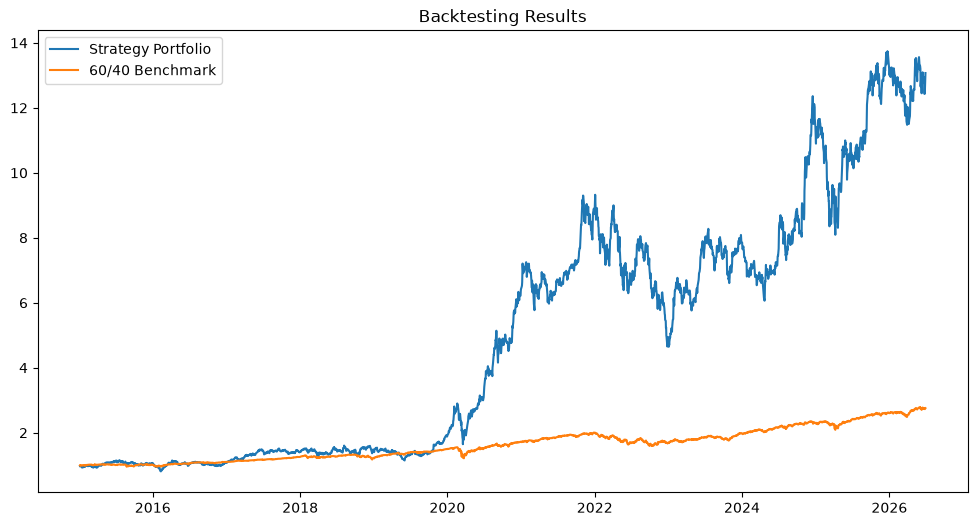

In [8]:
plt.figure(figsize=(12,6))

plt.plot(strategy_cum, label="Strategy Portfolio")
plt.plot(benchmark_cum, label="60/40 Benchmark")

plt.title("Backtesting Results")
plt.legend()
plt.show()

In [9]:
def performance(returns):
    total_return = (1 + returns).prod() - 1
    annual_return = (1 + returns.mean())**252 - 1
    sharpe = returns.mean() / returns.std() * np.sqrt(252)
    max_drawdown = (returns.cumprod() / returns.cumprod().cummax() - 1).min()
    
    return total_return, annual_return, sharpe, max_drawdown

strategy_metrics = performance(strategy_returns)
benchmark_metrics = performance(benchmark_returns)

print("Strategy:", strategy_metrics)
print("Benchmark:", benchmark_metrics)

Strategy: (np.float64(12.071103672118257), np.float64(0.3155536721639458), np.float64(0.8673756948147126), np.float64(-1.012852044506324))
Benchmark: (np.float64(1.7548149905830321), np.float64(0.09917203321101975), np.float64(0.8564701872869189), np.float64(-1.0000003197247618))


## Backtesting Conclusion

The strategy portfolio is compared against a simple 60/40 benchmark.

- If strategy returns are higher → model adds value
- If Sharpe ratio is higher → better risk-adjusted performance
- Drawdown shows downside risk exposure

This backtest helps evaluate whether model-based portfolio optimization provides real-world benefits.